## Bài tập 3: Phân rã chuỗi thời gian (Decomposition)
Thực hành phân tích xu hướng và tính mùa vụ của dữ liệu nhiệt độ.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
# Hàm chuyên dùng để phân tích chuỗi thời gian. sử dụng seasonal_decompose và STL
from statsmodels.tsa.seasonal import seasonal_decompose, STL 

# Cấu hình để Jupyter Notebook hiển thị biểu đồ đẹp hơn
%matplotlib inline
import warnings # Hạn chế những cảnh bảo để trực quan dễ nhìn hơn 
warnings.filterwarnings('ignore')

### Bước 1: Đọc và tiền xử lý dữ liệu
Chuyển đổi dữ liệu từ tần suất ngày (Daily) sang tần suất tháng (Monthly).

In [ ]:
# Lưu ý: Đảm bảo file 'nhiet_do.csv' nằm cùng thư mục với notebook này
df = pd.read_csv('../data/raw/daily-min-temperatures.csv')

# Chuyển đổi 'Date' sang kiểu thời gian và đặt làm index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Chuyển từ dữ liệu ngày sang trung bình tháng ('ME' hoặc 'M')
df_monthly = df['Temp'].resample('ME').mean()

print("5 dòng dữ liệu đầu tiên sau khi chuyển sang tháng:")
display(df_monthly.head())

5 dòng dữ liệu đầu tiên sau khi chuyển sang tháng:


Date
1981-01-31    17.712903
1981-02-28    17.678571
1981-03-31    13.500000
1981-04-30    12.356667
1981-05-31     9.490323
Freq: ME, Name: Temp, dtype: float64

### Bước 2: Phân rã chuỗi thời gian
Sử dụng phương pháp STL (Seasonal and Trend decomposition using Loess) để tách bóc dữ liệu.

In [ ]:
# Tham số period=12 ứng với chu kỳ 12 tháng trong năm
# Tham số seasonal = 13, vì cần loess của STL cần tìm khoảng chính giữa nên sử dụng số lẻ
stl = STL(df_monthly, seasonal=13, period=12)
result = stl.fit()


### Bước 3: Trực quan hóa kết quả
Vẽ 4 thành phần: Observed (Dữ liệu gốc), Trend (Xu hướng), Seasonal (Mùa vụ), Residual (Phần dư/Nhiễu).

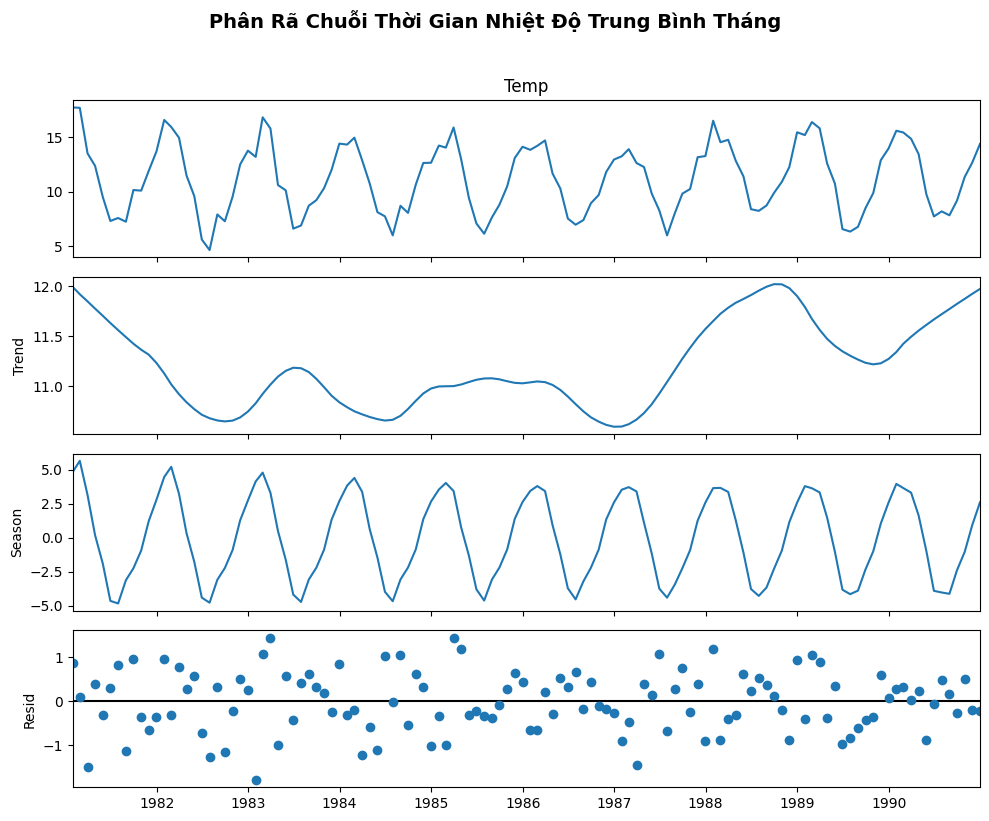

In [25]:
fig = result.plot()
fig.set_size_inches(10, 8)

plt.suptitle('Phân Rã Chuỗi Thời Gian Nhiệt Độ Trung Bình Tháng', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chi tiết các công thức tính toán theo loess của STL 
**công thức chung tìm các tham số**: Y(t) = T(t) + S(t) + R(t)
**công thức trọng số**: W=(1-(d/dmax)^3)^3 
**sau khi sử dụng tìm Seasonal** thì đem khử S(t) sau đó tiếp tục thực hiện với Trend
**tìm trend xong thì khử trend** --> kết quả cuối cùng sẽ là của R(t) 

### 1. Xu hướng (Trend): Tăng hay giảm?
* **Nhận xét chung:** Xu hướng dài hạn trong giai đoạn này không phải là một đường thẳng đi ngang hoàn toàn, mà có sự biến động uốn lượn theo chu kỳ dài hạn.
* **Chi tiết từ biểu đồ:** 
  * Từ năm 1981, đường xu hướng giảm dần từ mốc khoảng 12.0°C xuống điểm thấp nhất khoảng 10.6°C vào giai đoạn 1983 – 1985.
  * Sau đó, xu hướng đảo chiều tăng mạnh trở lại, đạt đỉnh khoảng 12.0°C vào năm 1988 trước khi có xu hướng điều chỉnh nhẹ về cuối giai đoạn năm 1990.

### 2. Mùa vụ (Seasonal): Mạnh hay yếu?
* **Nhận xét chung:** Yếu tố mùa vụ rất mạnh mẽ, rõ nét và mang tính ổn định cực kỳ cao qua các năm.
* **Chi tiết từ biểu đồ:** 
  * Biên độ dao động của thành phần mùa vụ rất lớn, đều đặn nằm trong khoảng từ -5.0°C đến +5.0°C (tổng biên độ chênh lệch giữa đỉnh và đáy lên tới khoảng 10°C).
  * Các con sóng mùa vụ lặp lại y hệt nhau về hình dáng và biên độ qua từng năm (từ 1981 đến 1990), phản ánh quy luật thay đổi nhiệt độ theo mùa (nóng/lạnh) vô cùng chi phối tại khu vực này.

### 3. Residual có giống white noise không?
* **Nhận xét chung:** Phần dư (Residual) hoàn toàn giống với nhiễu trắng (white noise).
* **Chi tiết từ biểu đồ:** 
  * Các điểm dữ liệu phân bố tản mác, ngẫu nhiên và đối xứng quanh đường chuẩn giá trị 0 (hầu hết nằm trong khoảng từ -1.5 đến +1.5). 
  * Không có bất kỳ hình sin, chu kỳ hay cấu trúc xu hướng nào còn sót lại trong biểu đồ phần dư này, chứng tỏ mô hình STL đã bóc tách triệt để các thành phần quy luật (Trend và Season), chỉ để lại sai số ngẫu nhiên của tự nhiên.